In [3]:
# ============================================================
# CELL 1: IMPORT, LOAD DATA & FEATURE ENGINEERING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, f1_score, roc_auc_score,
                             precision_recall_curve, precision_score,
                             accuracy_score, balanced_accuracy_score)
import xgboost as xgb

print("=" * 70)
print("PIPELINE: IF+LOF (Anomaly) + XGBoost (Supervised) + BLEND ENSEMBLE")
print("=" * 70)

# Load data
data = pd.read_excel(r'/Users/nasauramecca/collage/smester 4/Machine Learning/aol/default of credit card clients.xls', header=1)
data.columns = data.columns.str.strip()
data['EDUCATION'] = data['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
data['MARRIAGE']  = data['MARRIAGE'].replace({0: 3})
TARGET = 'default payment next month'

print(f"Data shape: {data.shape}")
print(f"Default rate: {data[TARGET].mean():.2%}")

PIPELINE: IF+LOF (Anomaly) + XGBoost (Supervised) + BLEND ENSEMBLE
Data shape: (30000, 25)
Default rate: 22.12%


In [4]:
# ============================================================
# CELL 2: FEATURE ENGINEERING
# ============================================================
df = data.copy()

PAY_COLS = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
BILL_COLS = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
AMT_COLS = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# ============ DELAY FEATURES ============
df['TOTAL_DELAY'] = df[PAY_COLS].clip(lower=0).sum(axis=1)
df['NUM_LATE_MONTHS'] = (df[PAY_COLS] > 0).sum(axis=1)
df['MAX_DELAY'] = df[PAY_COLS].max(axis=1)
df['DELAY_TREND'] = df['PAY_0'] - df['PAY_6']
df['RECENT_ESCALATION'] = (df['PAY_0'] > df['PAY_2']).astype(int) + (df['PAY_2'] > df['PAY_3']).astype(int)

# ============ UTILIZATION FEATURES ============
df['UTILIZATION_RATIO'] = (df['BILL_AMT1'] / df['LIMIT_BAL'].clip(lower=1)).clip(0, 2)
df['AVG_UTILIZATION'] = (df[BILL_COLS].mean(axis=1) / df['LIMIT_BAL'].clip(lower=1)).clip(0, 2)
df['HIGH_UTIL_FLAG'] = (df['UTILIZATION_RATIO'] > 0.9).astype(int)

# ============ PAYMENT RATIO FEATURES ============
for i in range(1, 7):
    bill = df[f'BILL_AMT{i}'].clip(lower=1)
    df[f'PAY_RATIO_{i}'] = (df[f'PAY_AMT{i}'] / bill).clip(0, 5)

PAY_RATIO_COLS = [f'PAY_RATIO_{i}' for i in range(1, 7)]
df['AVG_PAY_RATIO'] = df[PAY_RATIO_COLS].mean(axis=1)
df['CHRONIC_UNDERPAY'] = (df[PAY_RATIO_COLS] < 0.05).sum(axis=1)
df['PAYMENT_TREND'] = df['PAY_AMT1'] - df['PAY_AMT6']

# ============ AGGREGATE FEATURES ============
df['TOTAL_PAYMENT'] = df[AMT_COLS].sum(axis=1)
df['TOTAL_BILL'] = df[BILL_COLS].sum(axis=1)
df['PAYMENT_GAP'] = (df['TOTAL_BILL'] - df['TOTAL_PAYMENT']).clip(lower=0)
df['BILL_GROWTH'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_VOLATILITY'] = df[BILL_COLS].std(axis=1)

# Kumpulkan semua fitur
ALL_FEATURES = (
    PAY_COLS + BILL_COLS + AMT_COLS
    + ['LIMIT_BAL', 'AGE', 'SEX', 'EDUCATION', 'MARRIAGE']
    + ['TOTAL_DELAY', 'NUM_LATE_MONTHS', 'MAX_DELAY', 'DELAY_TREND',
       'RECENT_ESCALATION', 'UTILIZATION_RATIO', 'AVG_UTILIZATION',
       'HIGH_UTIL_FLAG', 'AVG_PAY_RATIO', 'CHRONIC_UNDERPAY',
       'PAYMENT_TREND', 'TOTAL_PAYMENT', 'TOTAL_BILL', 'PAYMENT_GAP',
       'BILL_GROWTH', 'BILL_VOLATILITY']
    + PAY_RATIO_COLS
)

print(f"Total fitur: {len(ALL_FEATURES)}")

Total fitur: 45


In [5]:
# ============================================================
# CELL 3: FEATURE SELECTION (KORELASI DENGAN TARGET)
# ============================================================
print("\n" + "=" * 70)
print("FEATURE SELECTION BERDASARKAN KORELASI")
print("=" * 70)

corr_with_target = df[ALL_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corr_abs = corr_with_target.abs().sort_values(ascending=False)

print("Top 15 fitur paling korelasi ke target:")
for i, (feat, corr_val) in enumerate(corr_abs.head(15).items()):
    print(f"  {i+1:2d}. {feat:25s}: {corr_val:.4f}")

# Buang fitur dengan korelasi < 0.01 (noise)
CORR_CUTOFF = 0.01
SELECTED_FEATURES = corr_abs[corr_abs >= CORR_CUTOFF].index.tolist()
DROPPED_FEATURES = corr_abs[corr_abs < CORR_CUTOFF].index.tolist()

print(f"\nFitur dipakai  : {len(SELECTED_FEATURES)}")
print(f"Fitur dibuang  : {len(DROPPED_FEATURES)}")
print(f"Dibuang (noise): {DROPPED_FEATURES[:10]}..." if len(DROPPED_FEATURES) > 10 else f"Dibuang: {DROPPED_FEATURES}")


FEATURE SELECTION BERDASARKAN KORELASI
Top 15 fitur paling korelasi ke target:
   1. NUM_LATE_MONTHS          : 0.3984
   2. TOTAL_DELAY              : 0.3760
   3. MAX_DELAY                : 0.3310
   4. PAY_0                    : 0.3248
   5. PAY_2                    : 0.2636
   6. PAY_3                    : 0.2353
   7. PAY_4                    : 0.2166
   8. PAY_5                    : 0.2041
   9. RECENT_ESCALATION        : 0.1876
  10. PAY_6                    : 0.1869
  11. LIMIT_BAL                : 0.1535
  12. DELAY_TREND              : 0.1288
  13. AVG_PAY_RATIO            : 0.1274
  14. CHRONIC_UNDERPAY         : 0.1207
  15. AVG_UTILIZATION          : 0.1166

Fitur dipakai  : 42
Fitur dibuang  : 3
Dibuang: ['BILL_AMT5', 'BILL_AMT6', 'PAYMENT_GAP']


In [6]:
# ============================================================
# CELL 4: DATA SPLIT (TRAIN 80%, TEST 20%)
# ============================================================
print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

X = df[SELECTED_FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} (Default rate: {y_train.mean():.2%})")
print(f"Test  : {X_test.shape} (Default rate: {y_test.mean():.2%})")

# ============ SCALING ============
# Untuk Anomaly Detection (IF+LOF) - fit hanya pada data NORMAL
scaler_anomaly = RobustScaler()
X_train_normal = X_train[y_train == 0]
X_train_normal_sc = scaler_anomaly.fit_transform(X_train_normal)
X_test_sc = scaler_anomaly.transform(X_test)

# Untuk XGBoost - scaling semua data training
scaler_xgb = RobustScaler()
X_train_sc_xgb = scaler_xgb.fit_transform(X_train)
X_test_sc_xgb = scaler_xgb.transform(X_test)

print(f"\nX_train_normal_sc (untuk IF+LOF): {X_train_normal_sc.shape}")
print(f"X_train_sc_xgb (untuk XGBoost): {X_train_sc_xgb.shape}")


DATA SPLIT
Train : (24000, 42) (Default rate: 22.12%)
Test  : (6000, 42) (Default rate: 22.12%)

X_train_normal_sc (untuk IF+LOF): (18691, 42)
X_train_sc_xgb (untuk XGBoost): (24000, 42)


In [14]:
# ============================================================
# CELL 5: TRAIN IF + LOF (UNSUPERVISED - HANYA DATA NORMAL)
# ============================================================
print("\n" + "=" * 70)
print("TRAINING IF + LOF (Anomaly Detection)")
print("Hanya menggunakan data NORMAL dari training set")
print("=" * 70)

CONTAMINATION = y_train.mean()  # sekitar 0.22

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=500,
    max_samples=256,
    bootstrap=True,
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_normal_sc)
print("✓ Isolation Forest trained")

# LOF
lof = LocalOutlierFactor(
    n_neighbors=25,
    contamination=CONTAMINATION,
    novelty=True,
    n_jobs=-1
)
lof.fit(X_train_normal_sc)
print("✓ LOF trained")

# ============ HITUNG ANOMALY SCORES ============
def minmax_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

# Untuk test set
iso_test_raw = -iso_forest.score_samples(X_test_sc)
lof_test_raw = -lof.score_samples(X_test_sc)

iso_test_norm = minmax_norm(iso_test_raw)
lof_test_norm = minmax_norm(lof_test_raw)

# Untuk training (nanti dipakai di blend? Tidak, tapi kita hitung untuk keperluan optimasi)
iso_train_raw = -iso_forest.score_samples(X_train_sc_xgb)
lof_train_raw = -lof.score_samples(X_train_sc_xgb)
iso_train_norm = minmax_norm(iso_train_raw)
lof_train_norm = minmax_norm(lof_train_raw)

print(f"\nAnomaly Score Statistics (Test set):")
print(f"  IF  - Normal mean: {iso_test_norm[y_test==0].mean():.4f}, Default mean: {iso_test_norm[y_test==1].mean():.4f}")
print(f"  LOF - Normal mean: {lof_test_norm[y_test==0].mean():.4f}, Default mean: {lof_test_norm[y_test==1].mean():.4f}")


TRAINING IF + LOF (Anomaly Detection)
Hanya menggunakan data NORMAL dari training set
✓ Isolation Forest trained
✓ LOF trained

Anomaly Score Statistics (Test set):
  IF  - Normal mean: 0.2136, Default mean: 0.2843
  LOF - Normal mean: 0.0253, Default mean: 0.0270


In [8]:
# ============================================================
# CELL 6: OPTIMASI WEIGHT IF + LOF (MENGGUNAKAN TRAIN SET)
# ============================================================
print("\n" + "=" * 70)
print("OPTIMASI WEIGHT IF + LOF")
print("=" * 70)

# Gunakan data train untuk mencari weight optimal
best_f1 = 0
best_w_iso = 0.6

for w_iso in np.arange(0.3, 0.91, 0.05):
    w_lof = 1 - w_iso
    anomaly_train = w_iso * iso_train_norm + w_lof * lof_train_norm
    
    # Cari threshold optimal
    prec, rec, thr = precision_recall_curve(y_train, anomaly_train)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_f1_temp = np.max(f1_scores)
    
    if best_f1_temp > best_f1:
        best_f1 = best_f1_temp
        best_w_iso = w_iso

W_ISO = best_w_iso
W_LOF = 1 - W_ISO

print(f"Best weight: IF={W_ISO:.2f}, LOF={W_LOF:.2f}")
print(f"Best F1 (train): {best_f1:.4f}")

# Anomaly score final untuk test set
anomaly_score_test = W_ISO * iso_test_norm + W_LOF * lof_test_norm
anomaly_score_train = W_ISO * iso_train_norm + W_LOF * lof_train_norm

print(f"\nAnomaly Score - Test set:")
print(f"  Normal mean : {anomaly_score_test[y_test==0].mean():.4f}")
print(f"  Default mean: {anomaly_score_test[y_test==1].mean():.4f}")
print(f"  Difference  : {anomaly_score_test[y_test==1].mean() - anomaly_score_test[y_test==0].mean():.4f}")


OPTIMASI WEIGHT IF + LOF
Best weight: IF=0.90, LOF=0.10
Best F1 (train): 0.4025

Anomaly Score - Test set:
  Normal mean : 0.1948
  Default mean: 0.2586
  Difference  : 0.0638


In [9]:
# ============================================================
# CELL 7: TRAIN XGBOOST (SUPERVISED - TANPA ANOMALY SCORE)
# ============================================================
print("\n" + "=" * 70)
print("TRAINING XGBOOST (Supervised)")
print("Hanya menggunakan fitur original (TANPA anomaly score)")
print("=" * 70)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sc_xgb, y_train, verbose=False)
print("✓ XGBoost trained")

# Predict probabilities
xgb_proba_test = xgb_model.predict_proba(X_test_sc_xgb)[:, 1]
xgb_proba_train = xgb_model.predict_proba(X_train_sc_xgb)[:, 1]

print(f"\nXGBoost Probability - Test set:")
print(f"  Normal mean : {xgb_proba_test[y_test==0].mean():.4f}")
print(f"  Default mean: {xgb_proba_test[y_test==1].mean():.4f}")


TRAINING XGBOOST (Supervised)
Hanya menggunakan fitur original (TANPA anomaly score)
scale_pos_weight: 3.52
✓ XGBoost trained

XGBoost Probability - Test set:
  Normal mean : 0.3223
  Default mean: 0.5896


In [10]:
# ============================================================
# CELL 8: BLEND ENSEMBLE (WEIGHTED FUSION)
# ============================================================
print("\n" + "=" * 70)
print("BLEND ENSEMBLE")
print("Weighted fusion of Anomaly Score dan XGBoost Probability")
print("=" * 70)

# Grid search untuk mencari alpha optimal (bobot anomaly)
best_alpha = 0.15
best_f1_blend = 0
best_threshold_blend = 0.5

for alpha in np.arange(0.05, 0.51, 0.05):
    blend_train = alpha * anomaly_score_train + (1 - alpha) * xgb_proba_train
    prec, rec, thr = precision_recall_curve(y_train, blend_train)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx = np.argmax(f1_scores)
    
    if f1_scores[best_idx] > best_f1_blend:
        best_f1_blend = f1_scores[best_idx]
        best_alpha = alpha
        best_threshold_blend = thr[best_idx]

print(f"Optimal blending weight:")
print(f"  α (anomaly)      = {best_alpha:.2f}")
print(f"  1-α (XGBoost)    = {1 - best_alpha:.2f}")
print(f"  Threshold        = {best_threshold_blend:.4f}")
print(f"  F1 (train)       = {best_f1_blend:.4f}")

# Apply ke test set
blend_score_test = best_alpha * anomaly_score_test + (1 - best_alpha) * xgb_proba_test
y_pred_blend = (blend_score_test >= best_threshold_blend).astype(int)


BLEND ENSEMBLE
Weighted fusion of Anomaly Score dan XGBoost Probability
Optimal blending weight:
  α (anomaly)      = 0.05
  1-α (XGBoost)    = 0.95
  Threshold        = 0.4938
  F1 (train)       = 0.7210


In [15]:
# ============================================================
# CELL 9: EVALUATION METRICS (LOF+IF, XGBoost, BLEND)
# ============================================================
print("\n" + "=" * 70)
print("EVALUATION METRICS")
print("=" * 70)

def evaluate_model(y_true, y_pred, y_score, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_def = tp / (tp + fn) if (tp + fn) > 0 else 0
    recall_norm = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision_def = tp / (tp + fp) if (tp + fp) > 0 else 0
    precision_norm = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1_def = 2 * tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    balanced_acc = (recall_def + recall_norm) / 2
    auc = roc_auc_score(y_true, y_score)
    accuracy = (tn + tp) / len(y_true)
    
    return {
        'Model': model_name,
        'Recall_Default': recall_def,
        'Recall_Normal': recall_norm,
        'Precision_Default': precision_def,
        'Precision_Normal': precision_norm,
        'F1_Default': f1_def,
        'Balanced_Accuracy': balanced_acc,
        'AUC': auc,
        'Accuracy': accuracy,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

# ============ 1. LOF+IF ONLY ============
# Cari threshold optimal untuk LOF+IF (berdasarkan train set)
prec_anom, rec_anom, thr_anom = precision_recall_curve(y_train, anomaly_score_train)
f1_anom = 2 * prec_anom[:-1] * rec_anom[:-1] / (prec_anom[:-1] + rec_anom[:-1] + 1e-9)
best_idx_anom = np.argmax(f1_anom)
best_th_anom = thr_anom[best_idx_anom]
y_pred_anom = (anomaly_score_test >= best_th_anom).astype(int)
results_anom = evaluate_model(y_test, y_pred_anom, anomaly_score_test, "IF+LOF Only")

# ============ 2. XGBoost ONLY ============
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_train, xgb_proba_train)
f1_xgb = 2 * prec_xgb[:-1] * rec_xgb[:-1] / (prec_xgb[:-1] + rec_xgb[:-1] + 1e-9)
best_idx_xgb = np.argmax(f1_xgb)
best_th_xgb = thr_xgb[best_idx_xgb]
y_pred_xgb = (xgb_proba_test >= best_th_xgb).astype(int)
results_xgb = evaluate_model(y_test, y_pred_xgb, xgb_proba_test, "XGBoost Only")

# ============ 3. BLEND ENSEMBLE ============
results_blend = evaluate_model(y_test, y_pred_blend, blend_score_test, "BLEND ENSEMBLE")

# ============ PRINT COMPARISON ============
results_df = pd.DataFrame([results_anom, results_xgb, results_blend])
print("\n" + "=" * 80)
print("PERBANDINGAN KINERJA MODEL")
print("=" * 80)
print(results_df[['Model', 'Recall_Default', 'Precision_Default', 'F1_Default', 
                  'Balanced_Accuracy', 'AUC', 'Accuracy']].round(4).to_string(index=False))

print("\n" + "=" * 80)
print("DETAIL CONFUSION MATRIX")
print("=" * 80)
for res in [results_anom, results_xgb, results_blend]:
    print(f"\n{res['Model']}:")
    print(f"  TN={res['TN']:>5}  FP={res['FP']:>5}")
    print(f"  FN={res['FN']:>5}  TP={res['TP']:>5}")


EVALUATION METRICS

PERBANDINGAN KINERJA MODEL
         Model  Recall_Default  Precision_Default  F1_Default  Balanced_Accuracy    AUC  Accuracy
   IF+LOF Only          0.7566             0.2786      0.4072             0.6001 0.6410    0.5128
  XGBoost Only          0.6021             0.4866      0.5382             0.7109 0.7746    0.7715
BLEND ENSEMBLE          0.6051             0.4852      0.5386             0.7114 0.7749    0.7707

DETAIL CONFUSION MATRIX

IF+LOF Only:
  TN= 2073  FP= 2600
  FN=  323  TP= 1004

XGBoost Only:
  TN= 3830  FP=  843
  FN=  528  TP=  799

BLEND ENSEMBLE:
  TN= 3821  FP=  852
  FN=  524  TP=  803


NameError: name 'best_threshold' is not defined

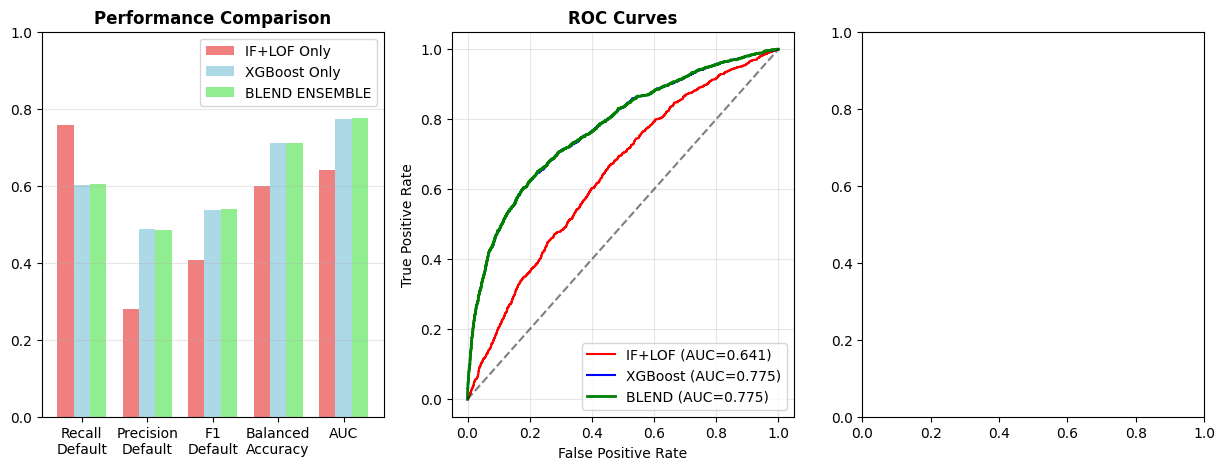

In [16]:
# ============================================================
# CELL 10: VISUALISASI PERBANDINGAN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Recall_Default', 'Precision_Default', 'F1_Default', 'Balanced_Accuracy', 'AUC']
x = np.arange(len(metrics))
width = 0.25

values_anom = [results_anom[m] for m in metrics]
values_xgb = [results_xgb[m] for m in metrics]
values_blend = [results_blend[m] for m in metrics]

axes[0].bar(x - width, values_anom, width, label='IF+LOF Only', color='lightcoral')
axes[0].bar(x, values_xgb, width, label='XGBoost Only', color='lightblue')
axes[0].bar(x + width, values_blend, width, label='BLEND ENSEMBLE', color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('_', '\n') for m in metrics])
axes[0].set_ylim(0, 1)
axes[0].set_title('Performance Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# ROC Curves
from sklearn.metrics import roc_curve
fpr_anom, tpr_anom, _ = roc_curve(y_test, anomaly_score_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba_test)
fpr_blend, tpr_blend, _ = roc_curve(y_test, blend_score_test)

axes[1].plot(fpr_anom, tpr_anom, 'r-', label=f'IF+LOF (AUC={results_anom["AUC"]:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, 'b-', label=f'XGBoost (AUC={results_xgb["AUC"]:.3f})')
axes[1].plot(fpr_blend, tpr_blend, 'g-', linewidth=2, label=f'BLEND (AUC={results_blend["AUC"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Summary text
summary = f"""
{'='*30}
FINAL RESULT
{'='*30}

IF+LOF Only:
  Recall   : {results_anom['Recall_Default']:.4f}
  Precision: {results_anom['Precision_Default']:.4f}
  F1       : {results_anom['F1_Default']:.4f}
  Balanced : {results_anom['Balanced_Accuracy']:.4f}

XGBoost Only:
  Recall   : {results_xgb['Recall_Default']:.4f}
  Precision: {results_xgb['Precision_Default']:.4f}
  F1       : {results_xgb['F1_Default']:.4f}
  Balanced : {results_xgb['Balanced_Accuracy']:.4f}

BLEND ENSEMBLE:
  Recall   : {results_blend['Recall_Default']:.4f}
  Precision: {results_blend['Precision_Default']:.4f}
  F1       : {results_blend['F1_Default']:.4f}
  Balanced : {results_blend['Balanced_Accuracy']:.4f}
  AUC      : {results_blend['AUC']:.4f}
  α (anomaly): {best_alpha:.2f}
  Threshold   : {best_threshold:.4f}
"""

axes[2].text(0.05, 0.95, summary, transform=axes[2].transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace')
axes[2].axis('off')
axes[2].set_title('Result Summary', fontweight='bold')

plt.suptitle('Model Comparison: IF+LOF vs XGBoost vs BLEND ENSEMBLE', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()